<a href="https://colab.research.google.com/github/yucelasan/superstore/blob/main/3A_Superstore_Gelir_Tahminleri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## BigQuery izinlerinin verilmesi ve proje datalarına erişim sağlandı

In [ ]:
from google.colab import auth
auth.authenticate_user()
from google.cloud import bigquery

import pandas as pd

client = bigquery.Client(project="superstore-484710")

In [ ]:
query = """
SELECT order_id, order_date, user_id, name_surname, total_basket
FROM `superstore-484710.dbt_superstore_int_superstore.int_orders_market`
"""

df = client.query(query).to_dataframe()


In [ ]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10235193 entries, 0 to 10235192
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   order_id      Int64  
 1   order_date    dbdate 
 2   user_id       Int64  
 3   name_surname  object 
 4   total_basket  float64
dtypes: Int64(2), dbdate(1), float64(1), object(1)
memory usage: 410.0+ MB


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
df = df.sort_values('order_date')

## Öncelikle gelirleri aylık olarak gruplayarak gelecek ayların gelirleri tahmin edilecek

Aylık zaman serisi oluşturuldu

In [ ]:
monthly_df = (
    df
    .groupby(pd.Grouper(key='order_date', freq='M'))
    .agg(
        total_revenue=('total_basket', 'sum'),
        order_count=('order_id', 'nunique'),
        unique_users=('user_id', 'nunique')
    )
    .reset_index()
)


/tmp/ipython-input-3320432794.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='order_date', freq='M'))


In [ ]:
monthly_df.shape

(32, 4)

AĞUSTOS 2023 yarım ay olduğu için çıkartmamız gerekiyor. Çünkü Prophet modeli tam aylar üzerinden çalışıyor.

In [ ]:
monthly_df = monthly_df[
    monthly_df['order_date'] < '2023-08-01'
]


Prophet modeli için veriler uygun formata çevirildi.

In [ ]:
prophet_df = monthly_df[['order_date', 'total_revenue']] \
    .rename(columns={'order_date': 'ds', 'total_revenue': 'y'})


Model aylık tahminleme için eğitildi.

In [ ]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_df)


INFO:prophet:n_changepoints greater than number of observations. Using 23.


15.08.2023 → 31.12.2023 tahminnlemesi yapıldı.

In [ ]:
future = model.make_future_dataframe(periods=5, freq='M')
forecast = model.predict(future)


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


2023 sonuna kadar olan tahmini alındı.

In [ ]:
forecast_2023 = forecast[
    (forecast['ds'] >= '2023-08-01') &
    (forecast['ds'] <= '2023-12-31')
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]


Ağustos’un ilk 14 günü gerçek, kalanı tahmin olmalı.

In [ ]:
aug_real = df[
    (df['order_date'] >= '2023-08-01') &
    (df['order_date'] <= '2023-08-14')
]['total_basket'].sum()

aug_pred_total = forecast_2023.loc[
    forecast_2023['ds'] == '2023-08-31', 'yhat'
].values[0]

aug_estimated_full = aug_real + (aug_pred_total * 17 / 31)


2023 kalan aylar için final tablo oluşturuldu.

In [ ]:
final_forecast = pd.DataFrame({
    'month': ['2023-08', '2023-09', '2023-10', '2023-11', '2023-12'],
    'estimated_revenue': [
        aug_estimated_full,
        *forecast_2023[forecast_2023['ds'] > '2023-08-31']['yhat'].values
    ]
})

final_forecast


,month,estimated_revenue
0,2023-08,3.086932e+09
1,2023-09,2.908996e+09
2,2023-10,2.989004e+09
3,2023-11,2.946637e+09
4,2023-12,3.047578e+09


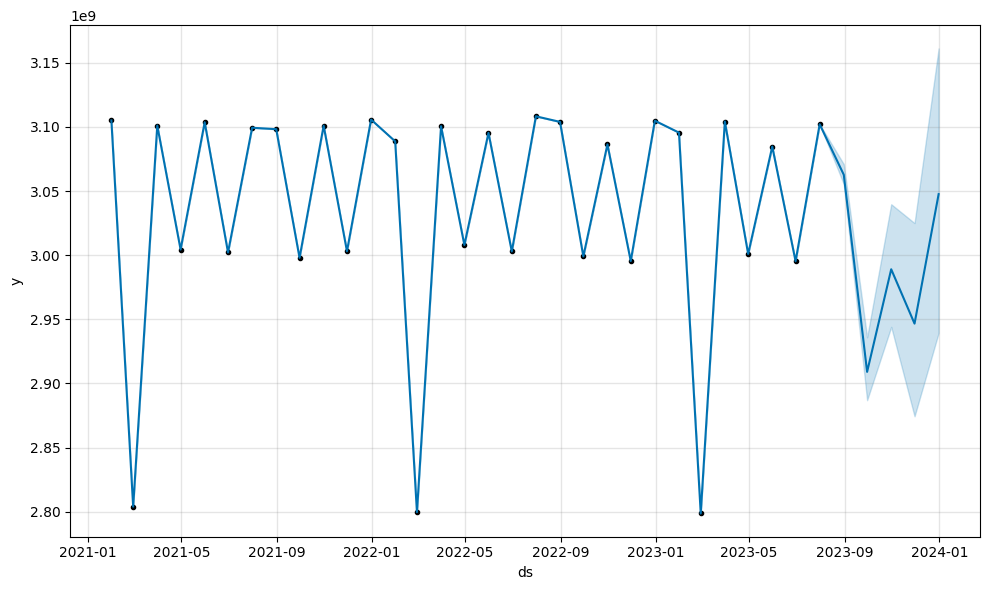

In [ ]:
model.plot(forecast);

Elde ettiğimiz sonuç beklediğimiz gibi gelmedi. Önceki senelere göre gelir paterni incelendiğinde gelecek aylar çok düşük geliyor. Bunun doğru olmamasının sebebi aylık bazda işlem yapılırken ağustos ayına ait dataların kaybedilmesinden kaynaklanıyor. Bu sebeple modeli günlük bazda eğiterek ilgili tahminlemeyi tekrar yapıyoruz ve sonrasında aylık olarak gruplayabiliyoruz.

## GÜNLÜK CİRO TAHMİNİ

Günlük ciro oluşturma için dateleri oluşturma.

In [ ]:
daily_df = (
    df
    .groupby(pd.Grouper(key='order_date', freq='D'))
    .agg(
        total_revenue=('total_basket', 'sum'),
        order_count=('order_id', 'nunique'),
        unique_users=('user_id', 'nunique')
    )
    .reset_index()
)


Prophet formatını günlük olarak düzenlendi.

In [ ]:
prophet_df = daily_df[['order_date', 'total_revenue']] \
    .rename(columns={'order_date':'ds', 'total_revenue':'y'})


Günlük Prophet modeli oluşturuldu.

In [ ]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)

model.fit(prophet_df)


2023 sonuna kadar GÜNLÜK tahminleme yapıldı

In [ ]:
future = model.make_future_dataframe(
    periods=(pd.Timestamp('2023-12-31') - pd.Timestamp('2023-08-14')).days,
    freq='D'
)

forecast = model.predict(future)


Sadece 15.08.2023 sonrası alındı.

In [ ]:
forecast_future = forecast[
    forecast['ds'] >= '2023-08-15'
][['ds', 'yhat']]


Günlük tahmini aylık olarak toplandı.

In [ ]:
monthly_forecast = (
    forecast_future
    .groupby(pd.Grouper(key='ds', freq='M'))
    .agg(
        estimated_revenue=('yhat', 'sum')
    )
    .reset_index()
)


/tmp/ipython-input-4190860905.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='ds', freq='M'))


Gerçek gelirler ile tahminlenen gelirler birleşik tablo haline getirildi.

In [ ]:
actual_2023 = daily_df[
    daily_df['order_date'] < '2023-08-15'
].groupby(pd.Grouper(key='order_date', freq='M')) \
 .agg(actual_revenue=('total_revenue','sum')) \
 .reset_index()

final_2023 = pd.merge(
    actual_2023,
    monthly_forecast,
    left_on='order_date',
    right_on='ds',
    how='outer'
)


/tmp/ipython-input-1414383409.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ].groupby(pd.Grouper(key='order_date', freq='M')) \


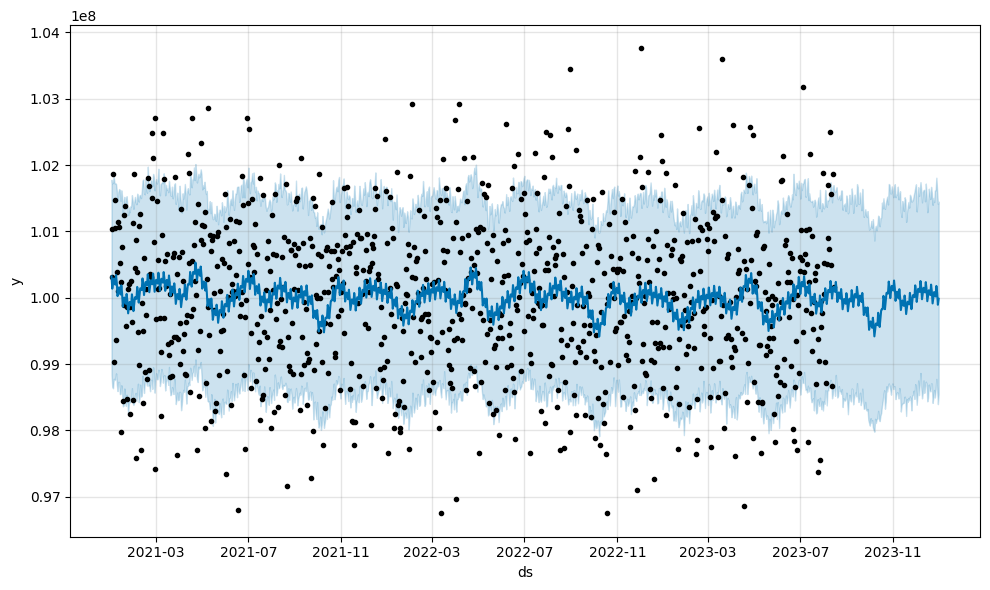

In [ ]:
model.plot(forecast);

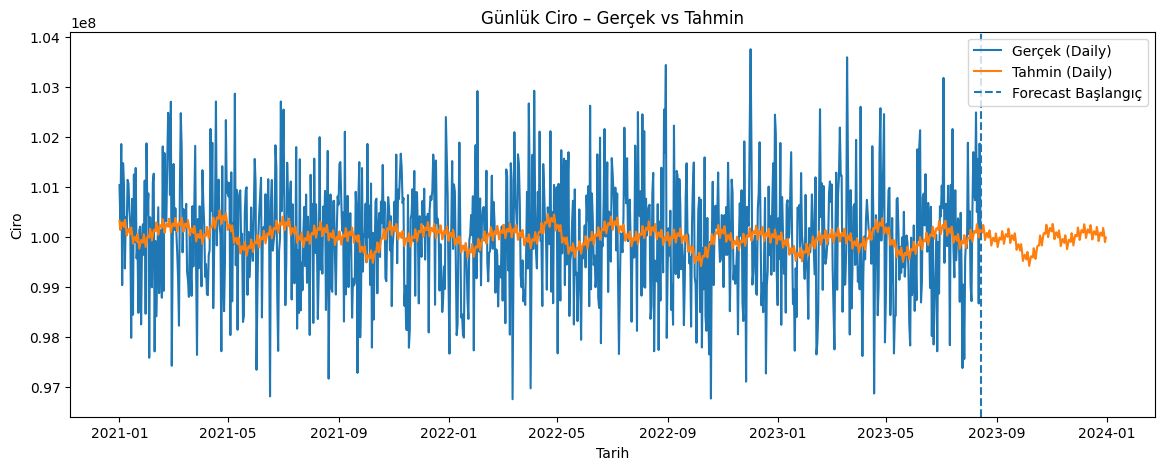

In [ ]:
import matplotlib.pyplot as plt

# Gerçek günlük veriler
actual_daily = daily_df.rename(
    columns={'order_date': 'ds', 'total_revenue': 'y'}
)

plt.figure(figsize=(14,5))
plt.plot(actual_daily['ds'], actual_daily['y'], label='Gerçek (Daily)')
plt.plot(forecast['ds'], forecast['yhat'], label='Tahmin (Daily)')
plt.axvline(pd.Timestamp('2023-08-15'), linestyle='--', label='Forecast Başlangıç')

plt.legend()
plt.title('Günlük Ciro – Gerçek vs Tahmin')
plt.xlabel('Tarih')
plt.ylabel('Ciro')
plt.show()


/tmp/ipython-input-3906790870.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='ds', freq='M'))
/tmp/ipython-input-3906790870.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='ds', freq='M'))


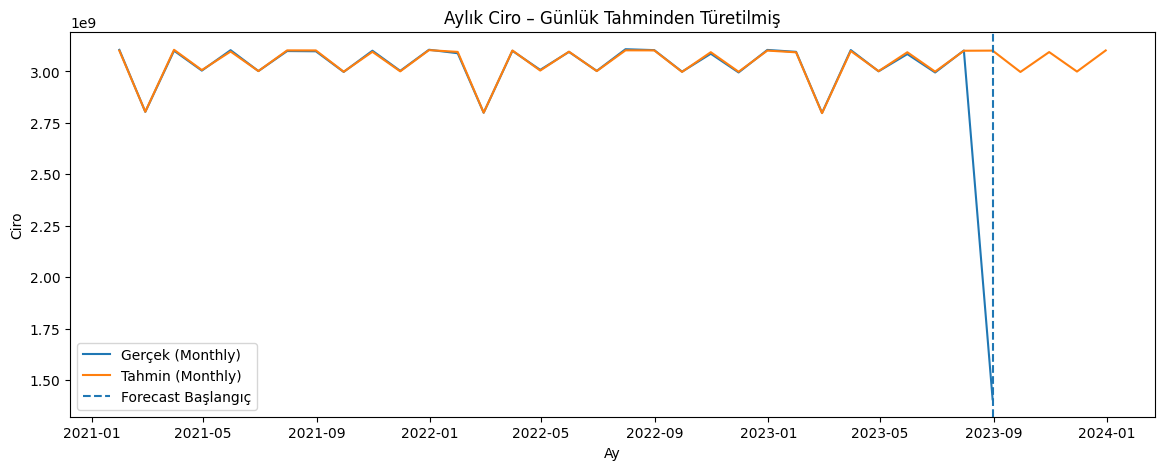

In [ ]:
# Günlük tahmini aylığa topla
monthly_from_daily = (
    forecast[['ds', 'yhat']]
    .groupby(pd.Grouper(key='ds', freq='M'))
    .sum()
    .reset_index()
)

# Gerçek aylıklar
actual_monthly = (
    actual_daily
    .groupby(pd.Grouper(key='ds', freq='M'))
    .agg(actual_revenue=('y','sum'))
    .reset_index()
)

plt.figure(figsize=(14,5))
plt.plot(actual_monthly['ds'], actual_monthly['actual_revenue'], label='Gerçek (Monthly)')
plt.plot(monthly_from_daily['ds'], monthly_from_daily['yhat'], label='Tahmin (Monthly)')
plt.axvline(pd.Timestamp('2023-08-31'), linestyle='--', label='Forecast Başlangıç')

plt.legend()
plt.title('Aylık Ciro – Günlük Tahminden Türetilmiş')
plt.xlabel('Ay')
plt.ylabel('Ciro')
plt.show()


## Verilerin toparlanıp bigquery e tablo olarak pushlanması

Gerçek veriler tablolaştırıldı.

In [ ]:
actual_daily = (
    daily_df[['order_date', 'total_revenue']]
    .rename(columns={
        'order_date': 'date',
        'total_revenue': 'revenue'
    })
)

actual_daily['data_type'] = 'actual'


Tahminlenen veriler tablolaştırıldı.

In [ ]:
forecast_daily = (
    forecast[['ds', 'yhat']]
    .rename(columns={
        'ds': 'date',
        'yhat': 'revenue'
    })
)

forecast_daily['data_type'] = 'forecast'

# Sadece 15.08.2023 – 31.12.2023
forecast_daily = forecast_daily[
    (forecast_daily['date'] >= '2023-08-15') &
    (forecast_daily['date'] <= '2023-12-31')
]


Her iki tablo birleştirildi.

In [ ]:
final_daily = pd.concat(
    [
        actual_daily[actual_daily['date'] < '2023-08-15'],
        forecast_daily
    ],
    ignore_index=True
)

final_daily = final_daily.sort_values('date')


In [ ]:
final_daily.head()
final_daily.tail()
final_daily.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1095 non-null   datetime64[ns]
 1   revenue    1095 non-null   float64       
 2   data_type  1095 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.8+ KB


Final tablo ilgili datasete pushlandı.

In [ ]:
PROJECT_ID = "superstore-484710"
DATASET_ID = "dbt_superstore_mart"
TABLE_ID = "daily_revenue_actual_forecast"

TABLE_FULL = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"


In [ ]:
from google.cloud import bigquery

client = bigquery.Client(project=PROJECT_ID)

job = client.load_table_from_dataframe(
    final_daily,
    TABLE_FULL,
    job_config=bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE"  # her çalıştırmada yeniler
    )
)

job.result()
print("✅ Data successfully pushed to BigQuery:", TABLE_FULL)


LoadJob<project=superstore-484710, location=EU, id=a7f81c9f-4d4b-4714-b089-de1bdb9d5ddf>